**Imports**

In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import json
import requests
from pathlib import Path
from time import sleep
import io, zipfile
from bs4 import BeautifulSoup as bs
import pyarrow.parquet as pq

**Pandas**

Leer archivo

In [ ]:
pd.read_excel(url, skiprows = 9) #se salta 9 lineas (es ejemplo)
pd.read_csv(archivo_csv)

Transformar a pandas

In [ ]:
archivo.to_pandas()

**JSON**

Abrir un archivo JSON (ej:restaurants.json)

In [ ]:
restaurantes = json.load(open('restaurants.json','r'))

# archivo grande, con encoding
datos_raw = json.load(open('restaurants.json','r', encoding='UTF-8'))

*Tenemos un archivo que se llama json_list*

In [ ]:
json_list = [
    { 
        'class': 'Year 1', 
        'student count': 35, 
        'room': 'A2',
        'info': {
            'teachers': { 
                'math': 'Emmy Noether', 
                'physics': 'Richard Feynman' 
            }
        },
        'students': [
            { 
                'name': 'Mary', 
                'sex': 'F', 
                'grades': { 'math': 75, 'physics': 98 } 
            },
            { 
                'name': 'James', 
                'sex': 'M', 
                'grades': { 'math': 80, 'physics': 78 } 
            },
        ]
    },
    { 
        'class': 'Year 2', 
        'student count': 28, 
        'room': 'A4',
        'info': {
            'teachers': { 
                'math': 'Alan Turing', 
                'physics': 'Vera Rubin' 
            }
        },
        'students': [
            { 'name': 'Tony', 'sex': 'M' },
            { 'name': 'Jacqueline', 'sex': 'F' },
        ]
    },
]

Ver los nombres de las columnas

In [ ]:
json_list[0].keys()

dict_keys(['class', 'student count', 'room', 'info', 'students'])

Transformar a df con pandas

In [ ]:
df = pd.DataFrame(json_list)
df.head()

,class,student count,room,info,students
0,Year 1,35,A2,"{'teachers': {'math': 'Emmy Noether', 'physics...","[{'name': 'Mary', 'sex': 'F', 'grades': {'math..."
1,Year 2,28,A4,"{'teachers': {'math': 'Alan Turing', 'physics'...","[{'name': 'Tony', 'sex': 'M'}, {'name': 'Jacqu..."


Transformar a df más limpio, students es una lista anidada, y debemos agregar class, student count, room e info

In [ ]:
all_students_grades= pd.json_normalize(json_list, sep="_", record_path=['students'], meta=['class','student count','room',['info','teachers','math'], ['info','teachers','physics']], max_level=None)
all_students_grades.head()

,name,sex,grades_math,grades_physics,class,student count,room,info_teachers_math,info_teachers_physics
0,Mary,F,75.0,98.0,Year 1,35,A2,Emmy Noether,Richard Feynman
1,James,M,80.0,78.0,Year 1,35,A2,Emmy Noether,Richard Feynman
2,Tony,M,NaN,NaN,Year 2,28,A4,Alan Turing,Vera Rubin
3,Jacqueline,F,NaN,NaN,Year 2,28,A4,Alan Turing,Vera Rubin


In [ ]:
#Otro ejemplo de desanidar
concert_data = pd.json_normalize(data=datos_raw['programs'], record_path='concerts', meta=['id', 'orchestra','programID', 'season'])

Almacenar en archivo json de esta forma

In [ ]:
all_students_grades.to_json('students.json')

**REQUESTS**

Tenemos un url `https://raw.githubusercontent.com/fivethirtyeight/data/master/college-majors/recent-grads.csv`


descargar

In [ ]:
csv_url = "https://raw.githubusercontent.com/fivethirtyeight/data/master/college-majors/recent-grads.csv"

Guardar

In [ ]:
out_dir = Path("data")
out_dir.mkdir(exist_ok=True)
csv_path = out_dir / "recent-grads.csv"

Solicitar datos

In [ ]:
r = requests.get(csv_url, timeout=30)
r.raise_for_status()  # Lanza error si el status no es 200
csv_path.write_bytes(r.content)

26872

Ver donde se guardo y que tamaño ocupa

In [ ]:
print("Guardado en:", csv_path.resolve())
print("Tamaño (bytes):", csv_path.stat().st_size)

Guardado en: C:\Users\Equipo\AppData\Local\Programs\Microsoft VS Code\data\recent-grads.csv
Tamaño (bytes): 26872


Transformar a df

In [2]:
df_csv = pd.read_csv(csv_path)
df_csv.head()

NameError: name 'csv_path' is not defined

Manejo de errores

In [ ]:
bad_url = "https://api.github.com/this/endpoint/does/not/exist"

try:
    r = requests.get(bad_url, timeout=5)
    r.raise_for_status()
except requests.exceptions.HTTPError as e:
    print("HTTPError:", e)
except requests.exceptions.Timeout:
    print("Timeout alcanzado.")
except requests.exceptions.RequestException as e:
    print("Error de red:", e)

HTTPError: 404 Client Error: Not Found for url: https://api.github.com/this/endpoint/does/not/exist


Otra forma de requests

In [ ]:
url = 'https://datos.gob.cl/dataset/c2969d8a-df82-4a6c-a1f8-e5eba36af6cf/resource/cbd329c6-9fe6-4dc1-91e3-a99689fd0254/download/pcma_20240917-oficio-4770_2013.xlsx'
respuesta = requests.get(url,stream=False)

open('puntosBip.xlsx', 'wb').write(respuesta.content) #Escribir respuesta en un archivo llamado puntosBip(ej)

#leemos el archivo local usando pandas
df = pd.read_excel('puntosBip.xlsx', engine='openpyxl',skiprows=9)
df

,CODIGO,ENTIDAD,NOMBRE DE FANTASIA,DIRECCIÓN,COMUNA,HORARIO REFERENCIAL,ESTE,NORTE,LONGITUD,LATITUD
0,1224,Fullcarga,MARION,LOS DURAZNOS 356 A,ESTACION CENTRAL,NaN,342846,6291414,-70.710197,-33.466599
1,3316,Fullcarga,NISSY,JOAQUIN EDWARDS BELLO 10999,LA PINTANA,NaN,349448,6285070,-70.622688,-33.563601
2,9878,Fullcarga,ERICHOPER,LOS RETAMOS 5615,HUECHURABA,NaN,339133,6307750,-70.623108,-33.377819
3,10347,Fullcarga,DON ORLANDO,ARTURO PRAT 5725 DPTO 11,RENCA,NaN,338900,6302656,-70.732925,-33.403622
4,10489,Fullcarga,NOLBERTO VALDES NAVARRO,CALLE 462 5994,PEÑALOLEN,NaN,354367,6292018,-70.568390,-33.501755
...,...,...,...,...,...,...,...,...,...,...
1574,124425,Fullcarga,GINO ANTONY CABRERA LARA,RIO ARHUELLES 3870,PUENTE ALTO,NaN,349313,6279537,-70.624313,-33.613178
1575,124426,Fullcarga,SERVICIOS INTEGRALES LTDA,ESQUINA BLANCA 0261,MAIPU,NaN,337008,6290673,-70.754868,-33.510967
1576,124428,Fullcarga,TODO FARMA 390,PASEO ESTADO 390,SANTIAGO,NaN,346580,6298855,-70.650444,-33.438625
1577,124436,Fullcarga,LA TIENDITA MAGICA,SALAR DE ACOSTAN 10398,LA FLORIDA,NaN,351106,6286304,-70.603859,-33.552422


Descomprimir **ZIP**

In [ ]:
url ='https://www.ine.gob.cl/docs/default-source/geodatos-abiertos/cartografia/censo-2017/siedu/shp/microdatos_manzana.zip?sfvrsn=972b0c54_3'
respuesta = requests.get(url, stream=True)

# Este dataset está en un archivo binario comprimido. Lo abrimos primero como un objeto tipo byte usando la librería io
archivoZip = zipfile.ZipFile(io.BytesIO(respuesta.content))

# Luego descomprimimos usando zipfile
archivoZip.extractall()

%ls Censo2017_16R_ManzanaEntidad_CSV # ver la ruta

dat_manz = pd.read_csv('Censo2017_16R_ManzanaEntidad_CSV/Censo2017_Manzanas.csv',delimiter=';') #abrir con ps en este caso es formato csv
print(dat_manz.head())

Mas sobre requests, sessions, headers en clase 5, 6 y 7(API)

**BeautifulSoup**    mas info clase 8

Leer el archivo html

In [ ]:
html_text=open('ejemplo.html','r').read()
html_text

abrir con bs

In [ ]:
soup = bs(html_text, "html.parser")

soup.table.find_all('tr') # encontrar cosas (ej:tr)
table = soup.find('table') 

Hacer df con bs desde el html

In [ ]:
df = pd.DataFrame(columns=['Curso', 'Creditos', 'nEstudiantes'])
table = soup.find('table')
rows = table.find_all('tr')

for row in rows[1::]:
    cols = row.find_all("td")
    col_text=[c.text for c in cols]
    print(col_text)
    new_row = pd.DataFrame({'Curso':col_text[0], 'Creditos':col_text[1], 'nEstudiantes':col_text[2]}, index=['Curso'])
    df = pd.concat([df, new_row], ignore_index=True)
df

Ejemplo de creación de df con bs y requests

In [ ]:
url = "https://en.wikipedia.org/wiki/2023_Rugby_World_Cup_squads"
headers = {"User-Agent": "imt2200-class-notebook"}
page = requests.get(url, headers=headers, timeout=10).text
soup = bs(page)
tables = soup.find_all('table')
# procesar la tabla 20 que tiene la escuadra de Chile
table = tables[19]

#creamos un DataFrame vacío con los títulos de la tabla
df = pd.DataFrame(columns = ['jugador','posicion','nacimiento','caps', 'club'])

# iterar sobre cada fila ('tr') para completar la información
for row in table.find_all('tr')[1::]:
    cols = row.find_all("td")
    #print(cols)
    cols = [col.text.strip() for col in cols]
    #print(cols)
    jugador = cols[0]
    posicion = cols[1]
    nacimiento = cols[2]
    caps = cols[3]
    club = cols[4]
    new_row = pd.DataFrame({'jugador': jugador, 'posicion': posicion, 'nacimiento': nacimiento,'caps':caps, 'club':club}, index=['jugador'])
    df = pd.concat([df, new_row], ignore_index=True)
df

,jugador,posicion,nacimiento,caps,club
0,Augusto Böhme,Hooker,(1997-06-11)11 June 1997 (aged 26),22,Selknam
1,Tomás Dussaillant,Hooker,(1990-10-06)6 October 1990 (aged 32),37,Selknam
2,Diego Escobar,Hooker,(2000-04-17)17 April 2000 (aged 23),5,Selknam
3,Javier Carrasco,Prop,(1997-08-24)24 August 1997 (aged 26),19,Selknam
4,Matías Dittus,Prop,(1993-07-16)16 July 1993 (aged 30),21,Périgueux
5,Iñaki Gurruchaga,Prop,(1995-10-13)13 October 1995 (aged 27),11,Selknam
6,Esteban Inostroza,Prop,(1994-01-01)1 January 1994 (aged 29),1,Selknam
7,Vittorio Lastra,Prop,(1996-03-26)26 March 1996 (aged 27),22,Selknam
8,Salvador Lues,Prop,(1999-11-06)6 November 1999 (aged 23),11,Selknam
9,Javier Eissman,Lock,(1997-03-21)21 March 1997 (aged 26),21,Selknam


**Transformación de datos**

Tipos de datos

In [ ]:
df.dtypes
df.info()
df['columna'].describe() # resumen estadistico valores numericos
df['columna'] = df['columna'].astype('nuevo_tipo') # cambiar tipo (category, int, string, float, etc.)

Info

In [ ]:
mean_datos = df['columna_valores_numericos'].mean() # promedio
categorias = df['columna'].unique() # ver categorias / valores unicos

# Cuántos registros están en la lista de categorías deseadas?
cat_simple = ['forwards','backs']
df['posicion'].isin(cat_simple).sum()

# Cambiar contenido de columna
# Mapeo de categorías originales a nuevas categorías
map_cats={'Hooker':'forwards',
          'Prop':'forwards',
          'Lock':'forwards',
          'Back row':'forwards',
          'Scrum-half':'backs',
          'Fly-half':'backs',
          'Centre':'backs',
          'Wing':'backs',
          'Fullback':'backs'}
df['posicion_simple'] = df['posicion'].map(map_cats)

# Agrupar y ver info
penguins.groupby(["species"]).agg({"body_mass_g": ["mean"]})

Datos duplicados

In [ ]:
# ver
duplicates = df.duplicated(keep=False)
dups = df[duplicates].sort_values(by='id')
dups

# quitar manteniendo first, last, etc.
df = df.drop_duplicates(keep='first')

Valores nulos

In [ ]:
# ver
nan_df = df['columna'].isna()
nan_df

# ver como df
df.isna()

df = df.replace('*', np.nan) # Reemplazar * por NaN
df.dropna(subset=['col2']) # Quitar filas con NaN en ej:col2 -no sobreescribe, hay que hacer copia-
df2['col2'] = df2['col2'].fillna(value='d') # Llenar los valores NaN con ej:d

# quitar
df.dropna(subset = ['columna'], inplace=True)

# filtrar columnas por porcentaje de nuls
maxi = len(bottleData) * 0.9
# Filtramos las columnas que tienen más de un 90% de datos no-nulos
bottleData = bottleData.loc[:, bottleData.notnull().sum() > maxi]


**Parquet**

Leer base parquet

In [ ]:
trips = pq.read_table('data\yellow_tripdata_2022-01.parquet') # Leer
trips = trips.to_pandas() # Transformar a pandas

**Limpieza de datos**

Orden

In [ ]:
trips_by_loc = trips[["PULocationID"]].groupby("PULocationID").size()  # Agrupar datos y saber tamaño
trips_by_loc.sort_values() # Ordenar valores
trips[(trips["PULocationID"] == 237) & (trips["passenger_count"] >= 1)] # Filtrar
df = df.drop(columns=['columna_a_eliminar']) # Eliminar columnas

# Seleccionar columnas
keep_cols = ['id','name','host_id','neighbourhood_group_cleansed','neighbourhood', 'minimum_nights', 'latitude','longitude','price','number_of_reviews']
df = df0[keep_cols]

#Cambiar a formato fecha
df['fecha'] = pd.to_datetime(df['fecha'], format = '%d/%m/%Y')

# Asignar numeros a categorias dentro de las columnas
titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1})


In [ ]:
# seleccionar strings (ej: (aged 26) )
df['edad'] = df['nacimiento'].str.slice(-3,-1)


**Combinación de datasets**

Concatenar

In [ ]:
df = pd.concat(frames, axis=1) # Concatenar hacia el lado
df = pd.concat(frames, axis=0, join='outer').reset_index(drop=True) # Concatenar hacia bajo

Ejemplo con merge

In [ ]:
clientes = pd.read_csv('data\\clientes.csv')
clientes

,Unnamed: 0,Rut,Edad
0,0,18001449,17
1,1,18005940,22
2,2,18012693,19
3,3,18025515,38
4,4,18036316,82
...,...,...,...
845,845,23448775,58
846,846,23454563,35
847,847,23460924,44
848,848,23464397,57


In [ ]:
clientes.drop(columns='Unnamed: 0',inplace=True)

In [ ]:
clientes

,Rut,Edad
0,18001449,17
1,18005940,22
2,18012693,19
3,18025515,38
4,18036316,82
...,...,...
845,23448775,58
846,23454563,35
847,23460924,44
848,23464397,57


In [ ]:
compras = pd.read_csv('data\\compras.csv')
compras

,Unnamed: 0,ID_transaccion,Rut,Fecha,Monto,Local
0,0,11468,18001449,12:33.7,76614,L15
1,1,19219,18001449,21:52.8,17547,L15
2,2,17850,18001449,05:46.6,36592,L5
3,3,21089,18001449,12:11.5,88654,L17
4,4,18385,18001449,55:28.4,60884,L15
...,...,...,...,...,...,...
12295,12295,19778,23490891,42:17.8,43573,L6
12296,12296,18275,23490891,32:28.8,44750,L15
12297,12297,15595,23490891,24:46.1,29884,L1
12298,12298,15206,23490891,22:09.2,89404,L10


In [ ]:
compras.drop(columns='Unnamed: 0',inplace=True)

In [ ]:
compras

,ID_transaccion,Rut,Fecha,Monto,Local
0,11468,18001449,12:33.7,76614,L15
1,19219,18001449,21:52.8,17547,L15
2,17850,18001449,05:46.6,36592,L5
3,21089,18001449,12:11.5,88654,L17
4,18385,18001449,55:28.4,60884,L15
...,...,...,...,...,...
12295,19778,23490891,42:17.8,43573,L6
12296,18275,23490891,32:28.8,44750,L15
12297,15595,23490891,24:46.1,29884,L1
12298,15206,23490891,22:09.2,89404,L10


Conectar los dos datasets

In [ ]:
clientes_compras = clientes.merge(compras, how='left', left_on='Rut', right_on='Rut')
clientes_compras

,Rut,Edad,ID_transaccion,Fecha,Monto,Local
0,18001449,17,11468.0,12:33.7,76614.0,L15
1,18001449,17,19219.0,21:52.8,17547.0,L15
2,18001449,17,17850.0,05:46.6,36592.0,L5
3,18001449,17,21089.0,12:11.5,88654.0,L17
4,18001449,17,18385.0,55:28.4,60884.0,L15
...,...,...,...,...,...,...
12296,23490891,77,19778.0,42:17.8,43573.0,L6
12297,23490891,77,18275.0,32:28.8,44750.0,L15
12298,23490891,77,15595.0,24:46.1,29884.0,L1
12299,23490891,77,15206.0,22:09.2,89404.0,L10


In [ ]:
# Conectar solo ciertas columas 
oceanData = bottleDataClean.merge(castDataClean[['Cst_Cnt', 'Date', 'Year', 'Month', 'Lat_Dec', 'Lon_Dec', 'Lat_Hem', 'Lon_Hem']], how='left', left_on='Cst_Cnt', right_on='Cst_Cnt')

In [ ]:
clientes_compras.groupby(by='Rut').agg({'Monto':'sum'}).reset_index() #sumar monto por cliente

,Rut,Monto
0,18001449,1173796.0
1,18005940,756752.0
2,18012693,352972.0
3,18025515,579702.0
4,18036316,360357.0
...,...,...
845,23448775,211176.0
846,23454563,574606.0
847,23460924,999396.0
848,23464397,691532.0


In [ ]:
pv = pd.pivot_table(clientes_compras, index='Rut', values='Monto', aggfunc="sum").reset_index()
pv # sumar monto por cliente en pv

,Rut,Monto
0,18001449,1173796.0
1,18005940,756752.0
2,18012693,352972.0
3,18025515,579702.0
4,18036316,360357.0
...,...,...
845,23448775,211176.0
846,23454563,574606.0
847,23460924,999396.0
848,23464397,691532.0


Distribución de montos de venta por edad

In [ ]:
merged = compras.merge(clientes, how='inner')
merged

,ID_transaccion,Rut,Fecha,Monto,Local,Edad
0,11468,18001449,12:33.7,76614,L15,17
1,19219,18001449,21:52.8,17547,L15,17
2,17850,18001449,05:46.6,36592,L5,17
3,21089,18001449,12:11.5,88654,L17,17
4,18385,18001449,55:28.4,60884,L15,17
...,...,...,...,...,...,...
12295,19778,23490891,42:17.8,43573,L6,77
12296,18275,23490891,32:28.8,44750,L15,77
12297,15595,23490891,24:46.1,29884,L1,77
12298,15206,23490891,22:09.2,89404,L10,77


In [ ]:
clientes_compras.groupby(by=['Edad']).agg({'Monto':['sum','mean']})

Monto              
             sum          mean
Edad                          
16    11411425.0  46577.244898
17     5523371.0  46414.882353
18     4420052.0  46042.208333
19     9332855.0  45974.655172
20     4217324.0  43033.918367
...          ...           ...
82     7277369.0  48194.496689
83    10775105.0  47467.422907
84     8976593.0  48261.252688
85     7506435.0  45219.487952
86     7455609.0  45461.030488

[71 rows x 2 columns]

Distribución de monto de ventas por edad y local

In [ ]:
clientes_compras.groupby(by=['Edad','Local']).agg({'Edad':'min','Monto':['sum','mean']})

Edad     Monto              
            min       sum          mean
Edad Local                             
16   L1      16  717569.0  47837.933333
     L10     16  558420.0  62046.666667
     L11     16  522022.0  43501.833333
     L12     16  824762.0  51547.625000
     L13     16  506336.0  36166.857143
...         ...       ...           ...
86   L5      86  299581.0  37447.625000
     L6      86  552715.0  46059.583333
     L7      86  555074.0  61674.888889
     L8      86  307270.0  43895.714286
     L9      86  295468.0  49244.666667

[1207 rows x 3 columns]

Fracción de ventas que representa cada cliente

In [ ]:
def as_perc(value, total):
    return value/float(total)

total_ventas = clientes_compras.Monto.sum()
clientes_compras['frac'] = clientes_compras[['Monto']].apply(as_perc,total=total_ventas)

clientes_compras

,Rut,Edad,ID_transaccion,Fecha,Monto,Local,frac
0,18001449,17,11468.0,12:33.7,76614.0,L15,0.000136
1,18001449,17,19219.0,21:52.8,17547.0,L15,0.000031
2,18001449,17,17850.0,05:46.6,36592.0,L5,0.000065
3,18001449,17,21089.0,12:11.5,88654.0,L17,0.000158
4,18001449,17,18385.0,55:28.4,60884.0,L15,0.000108
...,...,...,...,...,...,...,...
12296,23490891,77,19778.0,42:17.8,43573.0,L6,0.000077
12297,23490891,77,18275.0,32:28.8,44750.0,L15,0.000080
12298,23490891,77,15595.0,24:46.1,29884.0,L1,0.000053
12299,23490891,77,15206.0,22:09.2,89404.0,L10,0.000159


In [ ]:
clientes_compras.groupby(by='Rut').agg({'frac':'sum'}).reset_index()

,Rut,frac
0,18001449,0.002087
1,18005940,0.001346
2,18012693,0.000628
3,18025515,0.001031
4,18036316,0.000641
...,...,...
845,23448775,0.000375
846,23454563,0.001022
847,23460924,0.001777
848,23464397,0.001230


Concatenar agregando columna comun

In [ ]:
# Unificamos los datasets

adelie["species"] = "Adelie"
chinstrap["species"] = "Chinstrap"
gentoo["species"] = "Gentoo"

penguins = pd.concat([adelie, chinstrap, gentoo], ignore_index=True)
penguins

Más info sobre combinación y graficos en clase 13

**Exploración de datos**

In [ ]:
df.tail() # ver los ultimos datos
data_select[['x', 'y']].mean() # media
data_select[['x', 'y']].median() # mediana
data_select[['x', 'y']].var() # varianza
data_select[['x', 'y']].std() # desviación estándar
data_select[['x', 'y']].quantile(0.25) # percentil 25, 1er cuartil
corr = data_select['x'].corr(data_select['y']) # correlación / relación lineal

# **graficar por separado**

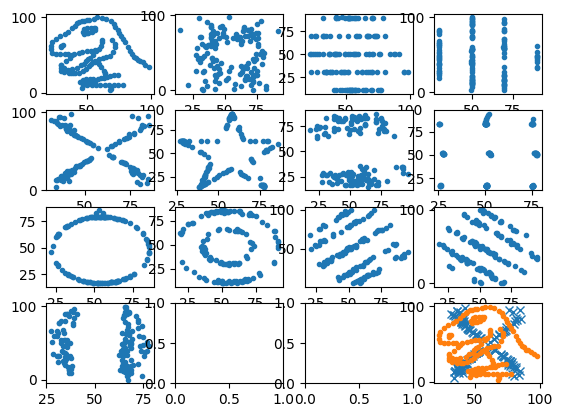

In [ ]:
data = pd.read_csv('datasaurus.csv')
datasets = data.dataset.unique()

fig, axs = plt.subplots(4, 4)

for i in range(len(datasets)):
    # selecciona el set
    data_select = data[data['dataset']==datasets[i]]
    # grafica
    axs[int(np.floor(i/4)), i%4].plot(data_select['x'], data_select['y'], '.')

# Graficar por encima
data_select = data[data['dataset']=='x_shape']
plt.plot(data_select['x'], data_select['y'], 'x')
data_select = data[data['dataset']=='dino']
plt.plot(data_select['x'], data_select['y'], '.')

In [ ]:
# EJEMPLO grafico dispersion diferenciar color por especie
sns.scatterplot(data=penguins, x="culmen_length_mm", y="flipper_length_mm", hue="species")
plt.title("Relación entre largo de aleta y largo de culmen")
plt.xlabel("Largo del culmen (mm)")
plt.ylabel("Largo de aleta (mm)")
plt.legend(title="Especie")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#Ejemplo histograma
sns.histplot(data=penguins, x="body_mass_g", hue="sex", element="step", bins=30)
plt.title("Distribución del peso corporal por sexo")
plt.xlabel("Peso corporal (g)")
plt.ylabel("Frecuencia")
plt.legend(title="Sexo")
plt.grid(alpha=0.3)
plt.show()

**SNS**

In [1]:
datasns = sns.load_dataset('titanic') # cargar dataset con sns

# graficar una columna del df con sns - dispersion
fig, ax = plt.subplots(1, 1, figsize=(9,3))
ax = sns.scatterplot(data.Age)
plt.xlabel('muestra')
plt.ylabel('edad')

# graficar una columna del df con sns - histograma/barra
sns.displot(data.Age, kde=False, bins=20)
plt.xlabel('edad')
plt.ylabel('cantidad')

# graficar una columna del df con sns - histograma
fig, ax = plt.subplots(1, 1, figsize=(7,3))
ax = sns.histplot(data=data, x='Age', bins=20)
ax.set_xlabel('edad')
ax.set_ylabel('cantidad')
ax.set(xlim=(0, 90))

# graficar una columna del df con sns - histograma con linea
fig, ax = plt.subplots(1, 1, figsize=(7,3))
ax = sns.histplot(data=data, x='Age', bins=20, kde=True)
ax.set_xlabel('edad')
ax.set_ylabel('cantidad')
ax.set(xlim=(0, 90))

# crear columnas con calculos 
dat['pct_D'] = dat['votes_D_2020']/dat['votes_total_2020']*100
dat['pct_R'] = dat['votes_R_2020']/dat['votes_total_2020']*100


NameError: name 'sns' is not defined

Valor	Qué hace	Visualización
'bars'	(Por defecto) Muestra barras clásicas de histograma, una al lado de otra o superpuestas.	📊 Gráfico de barras sólido.
'step'	Muestra solo el contorno (líneas) de cada barra, sin relleno.	▒ Líneas que forman la silueta del histograma.
'poly'	Dibuja una línea continua conectando la parte superior de cada barra (como una especie de gráfico de línea de densidad, pero discreto).	📈 Curva con picos y valles.

### 2.2 Estadísticas de resumen


- **Media** (`np.mean()`): es la suma de todos los valores, dividida por el número de puntos.
 
$$\mu=\frac{1}{n} \sum_{i=1}^n x_i $$

- **Mediana** (`np.median()`): es el valor medio de un conjunto de datos. Es inmune a valores extremos o outliers. Para calcularla, se ordenan los datos y se elige el valor que queda en la mitad. 
 
- **Percentiles** (`np.percentile()`): el percentil $p$, corresponde al valor que es mayor al $p\%$ de los datos.


- **Varianza** (`np.var()`): promedio de la distancia cuadrática de los datos a la media. Es una medida de la dispersión de los datos.

$$\rm{Var}=\frac{1}{n} \sum_{i=1}^n (x_i-\bar{x})^2$$

- **Desviación estándar** (`np.std()`): es la raíz cuadrada de la varianza. Está en la misma escala de unidades que los datos.

$$\sigma=\sqrt{\frac{1}{n} \sum_{i=1}^n (x_i-\bar{x})^2}$$

- **Covarianza** (`np.cov()`): es una medida de cómo dos cantidades varían juntas.
Es la media del producto entre las diferencias de los valores respecto a la media.

$$\rm{Cov} (x,y)=\frac{1}{n} \sum_{i=1}^n (x_i-\bar{x})(y_i-\bar{y})$$

- **Coeficiente de correlación de Pearson** (`np.corrcoef`): para tener una medida más general y aplicable de la correlación entre dos variables, necesitamos que sea adimensional. Por lo tanto dividimos la covarianza por las desviaciones estándar de $x$ e $y$. Esto define el coeficiente de correlación de Pearson ($\rho$).

$$\rho=\frac{\rm{Cov} (x,y)}{\sigma_x \sigma_y}$$

In [ ]:
# correlacion
corr = df.columna.corr(df.otra_columna)

# correlacion entre columnas numericas
''' # Seleccionar solo las columnas numéricas
numerical_data = df.select_dtypes(include=[float, int])
# Calcular la correlación entre las columnas numéricas
correlacion = numerical_data.corr() '''

# Mostrar la matriz de correlación
print(correlacion)


# percentil
quant = df.columna.quantile(ej: 0.9) # para percentil 10


## **GRAFICOS**

In [ ]:
# EJEMPLOS:

#### barra
x = urgenciasRespiratorias['GlosaCausa'].unique()
y = urgenciasRespiratorias['GlosaCausa'].value_counts()

plt.bar(x,y)
plt.xticks(rotation=90)

#### barra
# sumando cantidad de sobrevivientes por gate
cantidad_survived = df.groupby('Pclass')['Survived'].sum()
sns.barplot(x=cantidad_survived.index, y=cantidad_survived.values)
plt.title('Cantidad de Sobrevivientes por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Sobrevivientes')
plt.show()

#### barra
grupos_edad = ['Menores_1', 'De_1_a_4', 'De_5_a_14', 'De_15_a_64', 'De_65_y_mas']
total_por_grupo = urgenciasRespiratorias[grupos_edad].sum()
total_por_grupo.plot(kind='bar')

#### heatmap
correlacion = df[['Total', 'Registros validados']].corr()
import seaborn as sns
sns.heatmap(correlacion)

#### heatmap
sns.heatmap(corre, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('correlaciones')

#### Scatterplots e Histogramas
sns.pairplot(df)

#### Scatterplot color depende de una varial en este caso depth
sns.pairplot(data=oceanStudent, y_vars='Salnty', x_vars='T_degC', hue='Depthm', height=5)

#### Grafico de dispersion agregando puntos (en este caso ver datos de prueba y entrenamiento)
#Dividimos el dataframe de entrada
train, test = train_test_split(oceanStudent, test_size=0.25, random_state=2)
##
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)
plt.plot(test['T_degC'], test['Salnty'], '.', markersize=3, color='orange', zorder=1, label='Test')
plt.plot(train['T_degC'], train['Salnty'], '.', markersize=3, color='blue', zorder=0, label='Train')
ax.set_xlabel('Temperatura',fontsize=14)
ax.set_ylabel('Salinidad',fontsize=14)
ax.legend()


#### Barra
# Contar la cantidad de sobrevivientes (1) y no sobrevivientes (0)
sobrevivientes_count = df['Survived'].value_counts()
# Crear un gráfico de barras para visualizar la cantidad de sobrevivientes y no sobrevivientes
sns.barplot(x=sobrevivientes_count.index, y=sobrevivientes_count.values, palette='pastel')

## **Regresión lineal**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definir las variables dependiente e independiente
X = df_1_4[['Contaminacion_5_dias_antes']]  # Variable independiente
y = df_1_4['De_1_a_4']  # Variable dependiente

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # test_size 0.2 son 20% de prueba, random_state numero aleatorio para empezar

# Crear el modelo de regresión lineal
model = LinearRegression()

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# rmse r2 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [ ]:
# RMSE Y R2
'''Valores buenos o malos:

RMSE bajo = Buen modelo (idealmente más cercano a 0).

RMSE alto = Mal modelo (cuanto mayor el RMSE, peor es el modelo).

R² cercano a 1 = Buen modelo.

R² cercano a 0 o negativo = Mal modelo.'''

In [ ]:
# Dividir un df entero
from sklearn.model_selection import train_test_split
train, test = train_test_split(oceanStudent, test_size=0.25, random_state=2)

# ajustamos los datos para poder usarlo en un modelo en sklearn
y_train = np.array(train['Salnty'])
y_test = np.array(test['Salnty'])

X_train = np.array(train['T_degC'])
X_train = X_train.reshape(X_train.shape[0], 1)

X_test = np.array(test['T_degC'])
X_test = X_test.reshape(X_test.shape[0], 1)

# realizar modelo
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

linreg = LinearRegression()
linreg.fit(X_train, y_train)

# calculo de funcionamiento
y_pred_train = linreg.predict(X_train)
r2_lineal_train = linreg.score(X_train, y_train)
rmse_train = mean_squared_error(y_train, y_pred_train)

print('\nMétricas de Entrenamiento')
print(f'r^2 : {r2_lineal_train}')
print(f'RMSE {rmse_train}')
print(f'Coeficientes: {linreg.coef_[0], linreg.intercept_}')

#predecir valores de y para el set de prueba
y_pred_test = linreg.predict(X_test)
r2_lineal_test = linreg.score(X_test, y_test)
rmse_test = mean_squared_error(y_test, y_pred_test)

print('\nMétricas de Prueba')
print(f'r^2 : {r2_lineal_test}')
print(f'RMSE {rmse_test}')

# graficar
fig1, ax = plt.subplots(1,1, figsize=(7,7))

ax.plot(train['T_degC'], train['Salnty'],'o', markersize=4, mec='green', mfc='None', label='Train', alpha=0.5) 
ax.plot(test['T_degC'], test['Salnty'],'o', markersize=4, mec='blue', mfc='None', label='Test', alpha=0.5) 

xgrid = np.linspace(np.min(train['T_degC']), np.max(train['T_degC']), 100)
ax.plot(xgrid, linreg.predict(xgrid.reshape(100, 1)), label='Prediccion', color='k', ls='--')
ax.set_xlabel('Temperatura', fontsize=14)
ax.set_ylabel('Salinidad', fontsize=14)
ax.legend()

In [ ]:
# EJEMPLO

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definir las variables dependiente e independiente
X = df[['Pclass']]  # Variable independiente
y = df['Survived']  # Variable dependiente

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # test_size 0.2 son 20% de prueba, random_state numero aleatorio para empezar

# Crear el modelo de regresión lineal
model = LinearRegression()

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# rmse r2 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Graficar
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de dispersión
plt.figure(figsize=(10, 6))

# Graficar los puntos reales (scatter plot)
plt.scatter(X_test, y_test, color='blue', label='Datos reales')

# Graficar la línea de regresión (predicciones)
plt.plot(X_test, y_pred, color='red', label='Línea de regresión')

# Etiquetas y título
plt.title('Regresión Lineal: Pclass vs Survived')
plt.xlabel('Pclass')
plt.ylabel('Survived')

# Agregar leyenda
plt.legend()

# Mostrar gráfico
plt.show()


## **Regresión polimonial y multilineal**

In [ ]:
# función para evaluar modelos no lineales
def predict_model(poly_model, x_vals, poly_transformer=None):

    # optionally use the passed-in transformer
    if poly_transformer != None:
        dm = poly_transformer.fit_transform(x_vals)
    else:
        dm = x_vals
        
    # make the prediction at each x value
    prediction = poly_model.predict(dm)
    
    return(prediction)

# librería de modelos polinomiales
from sklearn.preprocessing import PolynomialFeatures

# comenzar con la figura con los datos
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.plot(train['T_degC'], train['Salnty'],'o', markersize=4, mec='green', mfc='None', label='Train', alpha=0.5) 
ax.plot(test['T_degC'], test['Salnty'],'o', markersize=4, mec='blue', mfc='None', label='Test', alpha=0.2) 

# grados a probar
polydegree = [1, 2, 3, 5, 8, 10, 12]

# almacenar el RMSE para cada modelo
error_test=[]
error_train=[]

# entrenar y probar cada modelo
for n in polydegree:
    # armar modelo
    transformer = PolynomialFeatures(n, include_bias=False)
    
    # entrenar el modelo
    expanded_train = transformer.fit_transform(X_train)
    reg_poly = LinearRegression().fit(expanded_train, y_train)
    
    # pruebas
    y_pred_train = predict_model(reg_poly, X_train, transformer)
    y_pred_test = predict_model(reg_poly, X_test, transformer)
    
    # calculo de error
    rmse_train = mean_squared_error(y_train, y_pred_train)
    rmse_test = mean_squared_error(y_test, y_pred_test)
    # agregar a listas de valores
    error_test.append(rmse_test)
    error_train.append(rmse_train)
    
    # graficar el modelo
    x_vals = np.linspace(np.min(train['T_degC']), np.max(train['T_degC']), 100).reshape(-1,1)
    prediction = predict_model(reg_poly, x_vals, transformer)
    ax.plot(x_vals, prediction, label='Prediction, n=%d'%n, ls='--')

ax.set_xlabel("Temperatura", fontsize=12)
ax.set_ylabel("Salinidad", fontsize=12)
ax.legend()



# gráfico de error
fig, ax = plt.subplots(1,1, figsize=(10, 6))

ax.plot(polydegree, error_train, 'o-', label='Train')
ax.plot(polydegree, error_test, 'o-', label='Test')

ax.set_xlabel("n", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.legend()




#### Multilineal


# ajustamos los datos para poder usarlo en un modelo en sklearn
y_train = np.array(train['Salnty'])
y_test = np.array(test['Salnty'])

X_train = np.array(train[['T_degC', 'Depthm', 'STheta']])
X_test = np.array(test[['T_degC', 'Depthm', 'STheta']])

# creamos y entrenamos el modelo
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# calculo de funcionamiento
y_pred_train = linreg.predict(X_train)
r2_lineal_train = linreg.score(X_train, y_train)
rmse_train = mean_squared_error(y_train, y_pred_train)

print('\nMétricas de Entrenamiento')
print(f'r^2 : {r2_lineal_train}')
print(f'RMSE {rmse_train}')
print(f'Coeficientes: {linreg.coef_[0], linreg.intercept_}')

#predecir valores de y para el set de prueba
y_pred_test = linreg.predict(X_test)
r2_lineal_test = linreg.score(X_test, y_test)
rmse_test = mean_squared_error(y_test, y_pred_test)

print('\nMétricas de Prueba')
print(f'r^2 : {r2_lineal_test}')
print(f'RMSE {rmse_test}')